# 3. Entrenamiento y Evaluación de Modelos Baseline

En este notebook, entrenaremos y evaluaremos dos modelos de clasificación para nuestro problema de mantenimiento predictivo:
1.  **Random Forest Classifier**
2.  **XGBoost Classifier**

Utilizaremos los datos preprocesados del notebook anterior. Para cada modelo, calcularemos un conjunto de métricas de evaluación, visualizaremos su rendimiento y lo guardaremos para su uso posterior en la API.

In [1]:
# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

# Configuración de visualización
sns.set_style("whitegrid")

# Definir rutas
processed_path = '../data/processed'
models_path = '../models'
figures_path = '../figures'

# Crear directorios si no existen
for path in [models_path, figures_path]:
    if not os.path.exists(path):
        os.makedirs(path)

## Cargar Datos Preprocesados

In [2]:
try:
    X_train = np.load(os.path.join(processed_path, 'X_train.npy'))
    y_train = np.load(os.path.join(processed_path, 'y_train.npy'))
    X_val = np.load(os.path.join(processed_path, 'X_val.npy'))
    y_val = np.load(os.path.join(processed_path, 'y_val.npy'))
    X_test = np.load(os.path.join(processed_path, 'X_test.npy'))
    y_test = np.load(os.path.join(processed_path, 'y_test.npy'))
    print("Datos cargados exitosamente.")
except FileNotFoundError:
    print("Error: No se encontraron los archivos .npy. Asegúrate de ejecutar el notebook 02_preprocessing.ipynb primero.")
    # Detener la ejecución si los datos no están disponibles
    X_train = None

Datos cargados exitosamente.


## Función Auxiliar de Evaluación

Para evitar repetir código, creamos una función que evalúa un modelo y muestra sus métricas, matriz de confusión y curva ROC.

In [3]:
def evaluate_model(model, X_test, y_test, model_name):
    """
    Evalúa un modelo de clasificación y devuelve un diccionario con las métricas.
    """
    # Realizar predicciones
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Calcular métricas
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_proba)
    }
    
    print(f"--- Métricas de Evaluación: {model_name} ---")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")
        
    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Anomalía'], yticklabels=['Normal', 'Anomalía'])
    plt.title(f'Matriz de Confusión - {model_name}')
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.savefig(os.path.join(figures_path, f'confusion_matrix_{model_name.replace(" ", "_").lower()}.png'))
    plt.show()
    
    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'AUC = {metrics["AUC-ROC"]:.4f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'Curva ROC - {model_name}')
    plt.xlabel('Tasa de Falsos Positivos (FPR)')
    plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
    plt.legend()
    plt.savefig(os.path.join(figures_path, f'roc_curve_{model_name.replace(" ", "_").lower()}.png'))
    plt.show()
    
    return metrics

## Modelo 1: Random Forest Classifier

Entrenando el modelo Random Forest...
Entrenamiento completado.
--- Métricas de Evaluación: Random Forest ---
Accuracy: 0.5515
Precision: 0.5435
Recall: 0.6098
F1-Score: 0.5747
AUC-ROC: 0.5757


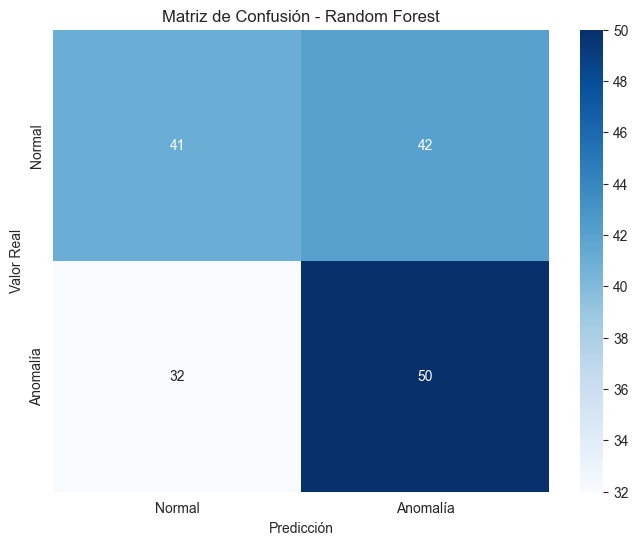

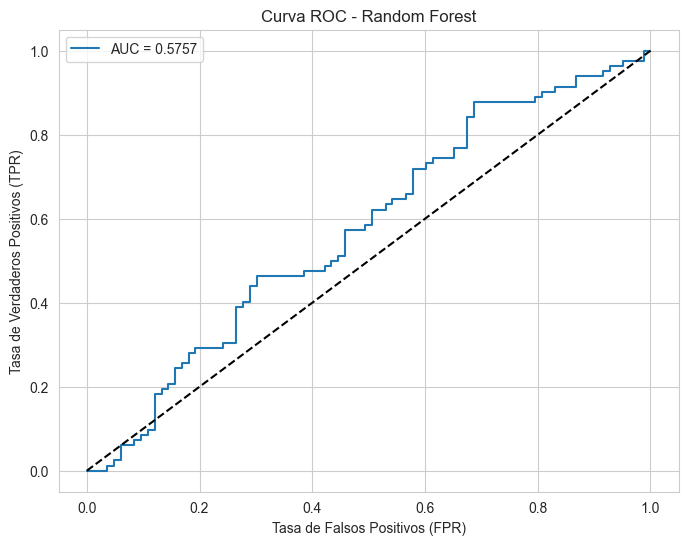


Modelo Random Forest guardado en: ../models/random_forest.pkl


In [4]:
if X_train is not None:
    # Inicializar y entrenar el modelo
    rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    print("Entrenando el modelo Random Forest...")
    rf_model.fit(X_train, y_train)
    print("Entrenamiento completado.")
    
    # Evaluar el modelo
    rf_metrics = evaluate_model(rf_model, X_test, y_test, "Random Forest")
    
    # Guardar el modelo
    rf_path = os.path.join(models_path, 'random_forest.pkl')
    joblib.dump(rf_model, rf_path)
    print(f"\nModelo Random Forest guardado en: {rf_path}")

## Modelo 2: XGBoost Classifier

Entrenando el modelo XGBoost...
Entrenamiento completado.
--- Métricas de Evaluación: XGBoost ---
Accuracy: 0.5636
Precision: 0.5568
Recall: 0.5976
F1-Score: 0.5765
AUC-ROC: 0.5610


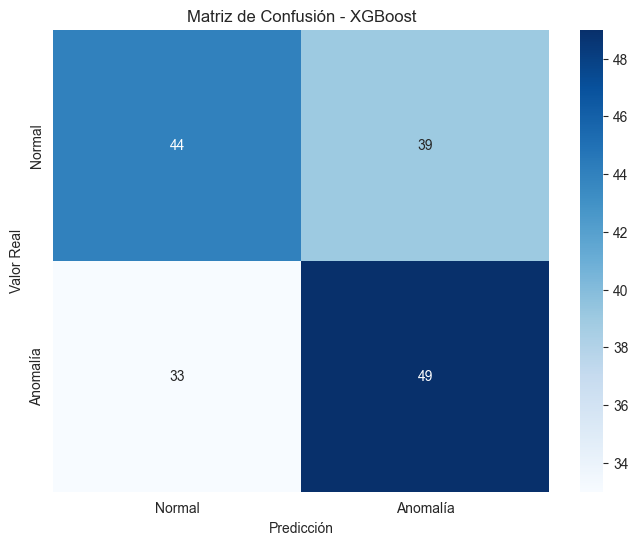

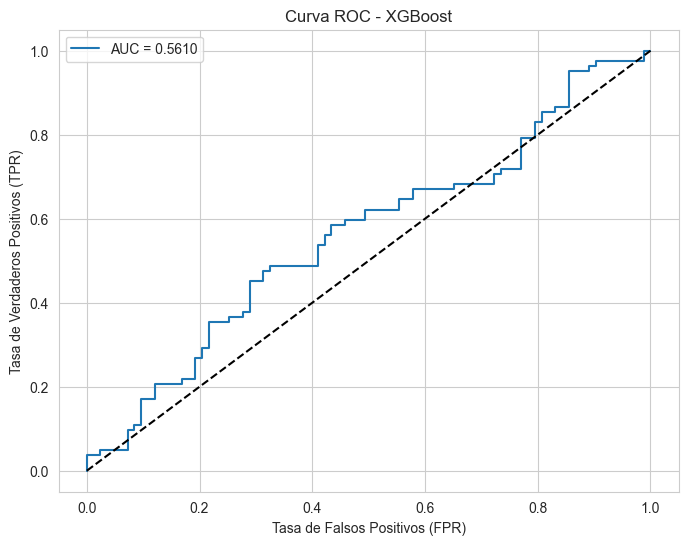


Modelo XGBoost guardado en: ../models/xgboost_model.pkl


In [5]:
if X_train is not None:
    # Inicializar y entrenar el modelo
    xgb_model = XGBClassifier(
        n_estimators=100, 
        max_depth=6, 
        learning_rate=0.1, 
        use_label_encoder=False, 
        eval_metric='logloss', 
        random_state=42
    )
    print("Entrenando el modelo XGBoost...")
    xgb_model.fit(X_train, y_train)
    print("Entrenamiento completado.")
    
    # Evaluar el modelo
    xgb_metrics = evaluate_model(xgb_model, X_test, y_test, "XGBoost")
    
    # Guardar el modelo
    xgb_path = os.path.join(models_path, 'xgboost_model.pkl')
    joblib.dump(xgb_model, xgb_path)
    print(f"\nModelo XGBoost guardado en: {xgb_path}")

## Comparación de Modelos

--- Tabla Comparativa de Métricas ---


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Random Forest,0.551515,0.543478,0.609756,0.574713,0.575669
XGBoost,0.563636,0.556818,0.597561,0.576471,0.560976



Tabla de comparación guardada como imagen en: ../figures/model_comparison.png


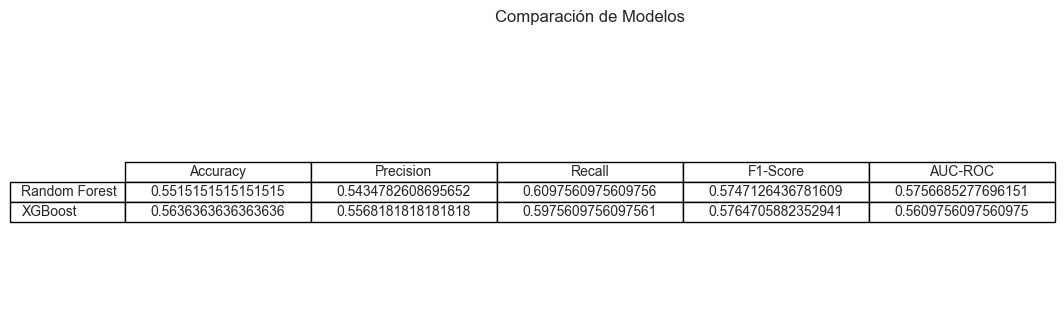

In [6]:
if 'rf_metrics' in locals() and 'xgb_metrics' in locals():
    # Crear DataFrame de comparación
    comparison_df = pd.DataFrame({
        'Random Forest': rf_metrics,
        'XGBoost': xgb_metrics
    }).T
    
    print("--- Tabla Comparativa de Métricas ---")
    display(comparison_df)
    
    # Guardar la tabla como una imagen
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.axis('tight')
    ax.axis('off')
    table = ax.table(cellText=comparison_df.values,
                     colLabels=comparison_df.columns,
                     rowLabels=comparison_df.index,
                     cellLoc='center',
                     loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.2)
    
    plt.title("Comparación de Modelos", y=1.2)
    comparison_img_path = os.path.join(figures_path, 'model_comparison.png')
    plt.savefig(comparison_img_path, bbox_inches='tight', dpi=300)
    print(f"\nTabla de comparación guardada como imagen en: {comparison_img_path}")
    plt.show()